# Business Case
The business case is on the inventory management. Keeping
Inventory of spare in various service centre to the market demand is
always a challenge as most service centres spends significant amount
in spare parts inventory costs. In spite of this, availability of spare
parts is been one of the problem areas.

PROJECT GOAL: 1. Create Predictive model for inventory forecasting so that
service centre achieve JIT standards.

# Data Preprocessing

**Importing  Libraries**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("service_data_full.csv")

In [6]:
df

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL
...,...,...,...,...,...,...,...
28477,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,SPROCKET RUBBER
28478,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,CLUTCH CABLE
28479,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,OIL FILTER
28480,06-01-19,06-01-19,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,DISC OIL


In [7]:
df.shape

(28482, 7)

In [8]:
df.describe()

,current_km_reading
count,28482.000000
mean,19348.003827
std,25246.722306
min,0.000000
25%,3988.000000
50%,12420.500000
75%,27905.000000
max,610112.000000


In [9]:
df.isnull().sum()

invoice_date              0
job_card_date             0
business_partner_name     0
vehicle_no                0
vehicle_model             0
current_km_reading        0
invoice_line_text        34
dtype: int64

In [10]:
df.dropna(inplace= True)

In [11]:
#checking for duplicates
df.duplicated().sum()

np.int64(367)

In [12]:
#Removing duplicates
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Converting to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['job_card_date'] = pd.to_datetime(df['job_card_date'])

# Exploratory Data Analyis

In [15]:
#Top 10 frequent customers
df['business_partner_name'].value_counts().head(10)

business_partner_name
venkXXXXXXXXXX    416
manjXXXXXXXXXX    354
prasXXXXXXXXXX    320
chanXXXXXXXXXX    311
raviXXXXXXXXXX    307
shivXXXXXXXXXX    305
hariXXXXXXXXXX    282
santXXXXXXXXXX    269
PRASXXXXXXXXXX    247
arunXXXXXXXXXX    238
Name: count, dtype: int64

In [16]:
#Most serviced vehicle models
df['vehicle_model'].value_counts().head(10)

vehicle_model
BAJAJ PULSAR 150            8498
BAJAJ AVENGER STREET 220    4162
BAJAJ PULSAR 220            2607
BAJAJ PULSAR 180            2237
BAJAJ PULSAR NS 200         2179
BAJAJ CT 100                1401
BAJAJ DISCOVER 125          1339
BAJAJ AVENGER STREET        1103
BAJAJ PLATINA                829
BAJAJ V150                   683
Name: count, dtype: int64

In [17]:
#Frequent service types (INVOICE LINE TEXT)
df['invoice_line_text'].value_counts().head(20)

invoice_line_text
ENGINE OIL            3780
CHAIN LUBRICATION     3417
GENERAL SERVICE       2132
AIR FILTER            1698
3M OIL                1615
CONSUMABLES           1582
POLISH                1236
DISC OIL               985
BRAKE SHOE             861
OIL FILTER             814
DISC PAD               530
WHEEL RUBBER           518
AIR FILTER CHECKUP     467
SPARK PLUG             414
CHAIN SPROCKET         394
SPROCKET RUBBER        344
SPROCKET BEARING       311
CHAIN OVERHAUL         283
CLUTCH CABLE           262
CLUTCH ASSEMBLY        209
Name: count, dtype: int64

In [18]:
#checking variance and standard deviation
df.select_dtypes(include='number').agg(['var', 'std'])

,current_km_reading
var,6.401802e+08
std,2.530178e+04


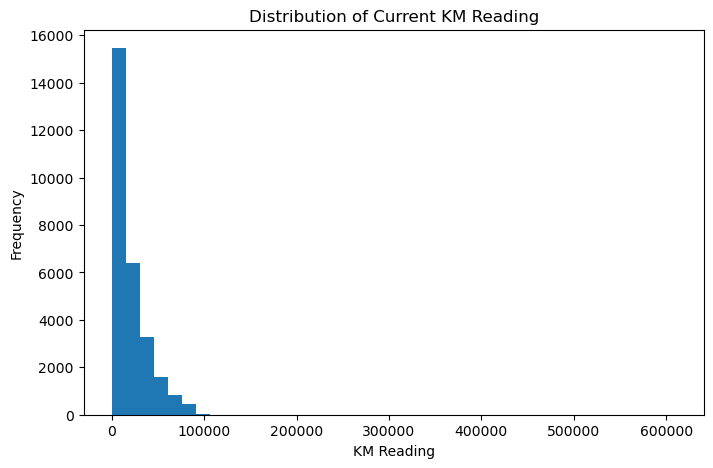

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df['current_km_reading'], bins=40)
plt.title('Distribution of Current KM Reading')
plt.xlabel('KM Reading')
plt.ylabel('Frequency')
plt.show()

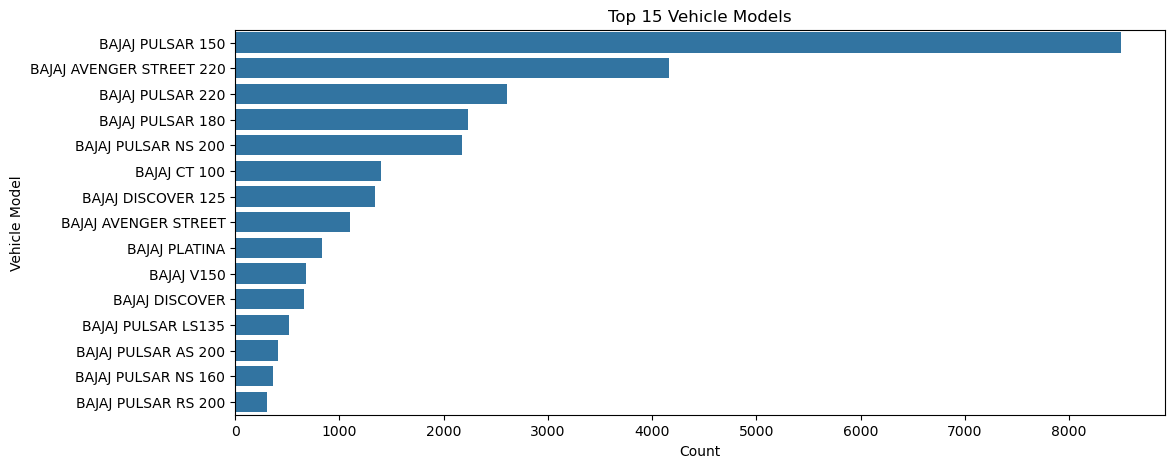

In [20]:
# Count Plot for Vehicle Model Frequency
plt.figure(figsize=(12,5))
sns.countplot(y=df['vehicle_model'], order=df['vehicle_model'].value_counts().index[:15])
plt.title('Top 15 Vehicle Models')
plt.xlabel('Count')
plt.ylabel('Vehicle Model')
plt.show()

Insight from above graph:
- Bajaj Pulsar 150 is highest in demand, Bajaj Avenger Street 220 second and Baja Pulsar 220 at third

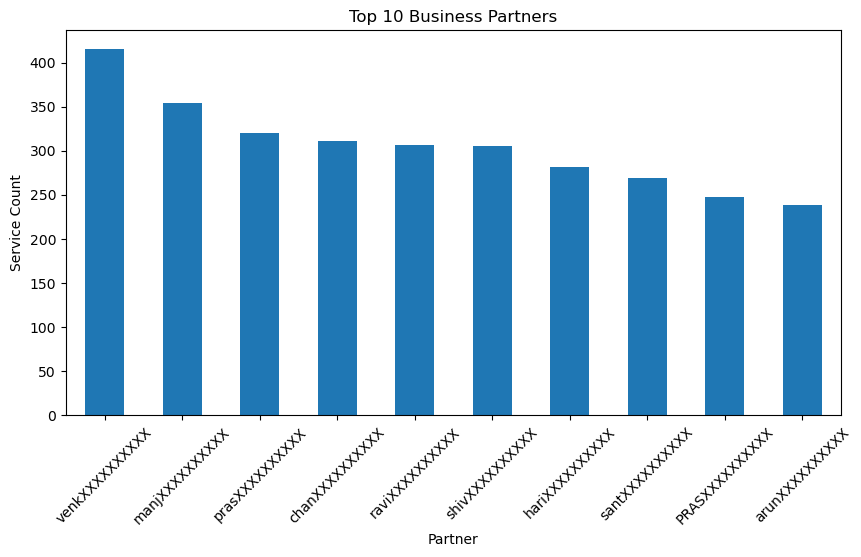

In [21]:
# Bar Chart for Top 10 Business Partners
top_bp = df['business_partner_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_bp.plot(kind='bar')
plt.title('Top 10 Business Partners')
plt.xlabel('Partner')
plt.ylabel('Service Count')
plt.xticks(rotation=45)
plt.show()

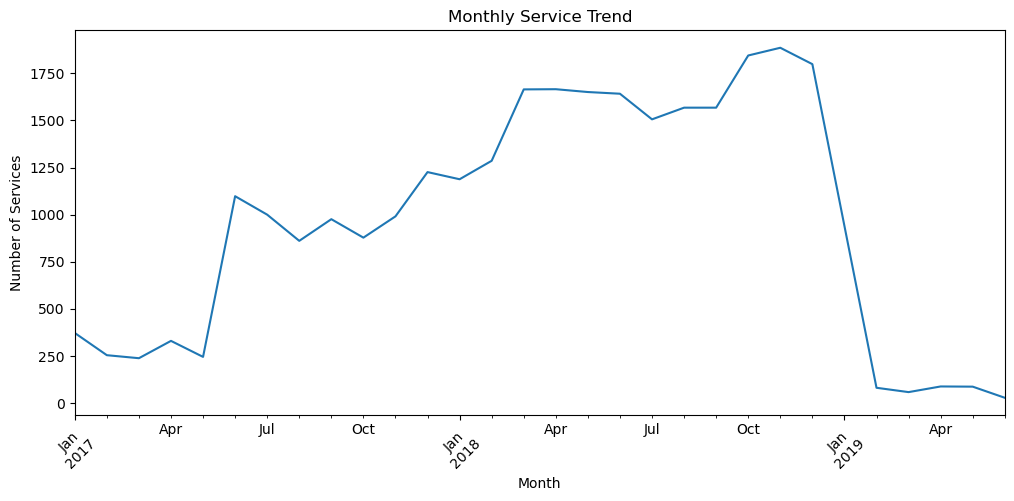

In [22]:
# Line Plot for Monthly Service Trend
df['Month'] = df['invoice_date'].dt.to_period('M')
monthly = df.groupby('Month').size()

plt.figure(figsize=(12,5))
monthly.plot()
plt.title('Monthly Service Trend')
plt.xlabel('Month')
plt.ylabel('Number of Services')
plt.xticks(rotation=45)
plt.show()

Insight from above graph:
- Service demand increases steadily through 2017–2018, peaks around Oct–Nov 2018, then drops sharply after Dec 2018, indicating seasonality and possible data gaps.

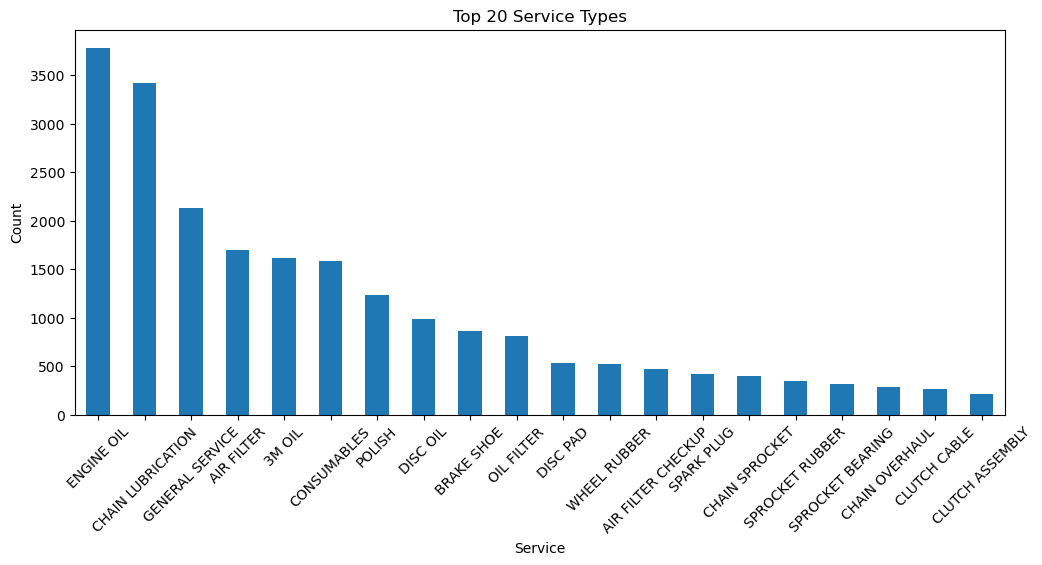

In [23]:
# Top 20 Service Types
plt.figure(figsize=(12,5))
df['invoice_line_text'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Service Types')
plt.xlabel('Service')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insight from above graph
- the demand of Engine oil is highest, Chain lubrication is second and at third is general service.

# Feature Engineering

In [24]:
df.isnull().sum()

invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        0
Month                    0
dtype: int64

1. Before creating new feature we will convert both 'invoice_date' and 'job_card_date' columns into correct date and time order using "to_datetime" feature from pandas.

In [25]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
df['job_card_date'] = pd.to_datetime(df['job_card_date'], errors='coerce')

2. At first we will create features using 'invoice_date' and 'job_card_date'to help the model understand time-related patterns—like how long it takes from a job being started to invoicing, or trends based on month, year,quarter and weekday which will make predictions more accurate and meaningful.

In [26]:
#Time-Based Features
df['invoice_month'] = df['invoice_date'].dt.month
df['invoice_year'] = df['invoice_date'].dt.year
df['invoice_quarter'] = df['invoice_date'].dt.quarter
df['invoice_weekday'] = df['invoice_date'].dt.weekday

3. Now we will create a featue called 'job_delay_days'which will help us understand delays between job creation and invoicing and allowing the model to learn patterns related to service time, efficiency, and potential delays.

In [27]:
# Job duration features
df['job_delay_days'] = (df['invoice_date'] - df['job_card_date']).dt.days

4. now we will divide 'current_km_reading' into different columns which which will give us new column called 'km_bucket' and this feature column will help the model capture maintenance or service patterns associated with different usage levels instead of relying on raw kilometer values.

In [28]:
# Vehicle usage feature
df['km_bucket'] = pd.cut(df['current_km_reading'],
bins=[0, 5000, 15000, 30000, 60000, 200000],labels=['NEW','LOW','MEDIUM','HIGH','VERY_HIGH'])

In [29]:
df.isnull().sum()

invoice_date               0
job_card_date              0
business_partner_name      0
vehicle_no                 0
vehicle_model              0
current_km_reading         0
invoice_line_text          0
Month                      0
invoice_month              0
invoice_year               0
invoice_quarter            0
invoice_weekday            0
job_delay_days             0
km_bucket                858
dtype: int64

In [30]:
df.dropna(inplace = True)

In [31]:
df.duplicated().sum()

np.int64(0)

5. Now we will standardize our categorical columns to clean and make the text consistent, so the same words aren’t treated as different just because of capital letters or extra spaces.

In [32]:
# Standardizing the data
df['invoice_line_text'] = (df['invoice_line_text'].str.upper().str.strip())

6. Now we will standardize different versions of the same text into one common value, so all variations of “clutch cable” are treated as the same item and don’t confuse the analysis or the model.

In [33]:
df['invoice_line_text'] = df['invoice_line_text'].replace({'CLUTCH CABLE': 'CLUTCH CABLE','Clutch cable': 'CLUTCH CABLE','clutch cable': 'CLUTCH CABLE'})

In [34]:
df.shape

(27223, 14)

7. Now we will group similar spare parts and services into meaningful categories, so instead of many messy text values, the data becomes simpler, cleaner, and easier for the model to learn useful patterns from.

In [35]:
def map_category(text):
    if 'CLUTCH' in text:
        return 'CLUTCH'
    elif 'BRAKE' in text or 'DISC' in text:
        return 'BRAKE'
    elif 'OIL' in text or 'BORE' in text or 'ENGINE' in text:
        return 'ENGINE'
    elif 'FILTER' in text:
        return 'FILTER'
    elif 'BATTERY' in text or 'COIL' in text or 'BULB' in text:
        return 'ELECTRICAL'
    elif 'TYRE' in text or 'WHEEL' in text:
        return 'TYRE_WHEEL'
    elif 'CHAIN' in text or 'SPROCKET' in text:
        return 'CHAIN_SPROCKET'
    elif 'FORK' in text or 'SHOCK' in text:
        return 'SUSPENSION'
    elif 'LABOUR' in text or 'SERVICE' in text:
        return 'SERVICE'
    else:
        return 'OTHER'


8. Now we will assign each invoice item to a clear category, making it easier to analyze and forecast inventory demand at a category level instead of dealing with raw, unstructured text.

In [36]:
# Creating inventory demand table
df['item_category'] = df['invoice_line_text'].apply(map_category)

9. Now we will summarize monthly demand for each item category, turning raw transaction data into a clean inventory demand table that shows how often each category is used every month, which helps in forecasting and planning stock levels.

In [37]:
# Creating inventory demand table
df['month'] = df['invoice_date'].dt.to_period('M')

inventory_df = (df.groupby(['month','item_category']).size().unstack(fill_value=0).reset_index())

In [38]:
inventory_df

item_category,month,BRAKE,CHAIN_SPROCKET,CLUTCH,ELECTRICAL,ENGINE,FILTER,OTHER,SERVICE,SUSPENSION,TYRE_WHEEL
0,2017-01,39,61,11,4,87,26,106,30,3,5
1,2017-02,21,44,6,4,74,21,58,20,0,6
2,2017-03,20,35,9,7,55,19,67,22,0,3
3,2017-04,26,50,14,7,78,21,81,25,0,7
4,2017-05,25,37,7,5,65,17,50,20,4,6
5,2017-06,129,162,36,15,273,68,251,84,12,30
6,2017-07,95,173,40,11,250,63,232,80,1,25
7,2017-08,70,133,56,12,205,50,230,67,9,15
8,2017-09,77,170,38,11,256,76,221,97,2,22
9,2017-10,75,137,28,18,209,72,203,82,4,25


In [39]:
inventory_df.shape

(29, 11)

In [40]:
inventory_df.columns

Index(['month', 'BRAKE', 'CHAIN_SPROCKET', 'CLUTCH', 'ELECTRICAL', 'ENGINE',
       'FILTER', 'OTHER', 'SERVICE', 'SUSPENSION', 'TYRE_WHEEL'],
      dtype='object', name='item_category')

# Encoding

Now with the help of Encoding we will convert item categories from text into numeric values, so machine-learning models can understand and use them for training and prediction.

In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['item_category_enc'] = le.fit_transform(df['item_category'])

Now we will try to capture how frequently each business partner appears in the data, helping the model understand partner importance or activity level instead of treating all partners as equal.

In [42]:
freq = df['business_partner_name'].value_counts()
df['partner_freq'] = df['business_partner_name'].map(freq)

In [43]:
inventory_df = (df.groupby(['month','item_category']).size().reset_index(name='demand'))

In [44]:
df

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text,Month,invoice_month,invoice_year,invoice_quarter,invoice_weekday,job_delay_days,km_bucket,item_category,month,item_category_enc,partner_freq
0,2017-05-30,2017-05-30,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL,2017-05,5,2017,2,1,0,HIGH,ENGINE,2017-05,4,303
1,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL,2017-02,2,2017,1,0,-114,NEW,ENGINE,2017-02,4,85
2,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH,2017-02,2,2017,1,0,-114,NEW,OTHER,2017-02,6,85
3,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES,2017-02,2,2017,1,0,-114,NEW,OTHER,2017-02,6,85
4,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL,2017-02,2,2017,1,0,-114,NEW,ENGINE,2017-02,4,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28477,2019-06-01,2019-06-01,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,SPROCKET RUBBER,2019-06,6,2019,2,5,0,LOW,CHAIN_SPROCKET,2019-06,1,175
28478,2019-06-01,2019-06-01,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,CLUTCH CABLE,2019-06,6,2019,2,5,0,LOW,CLUTCH,2019-06,2,175
28479,2019-06-01,2019-06-01,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,OIL FILTER,2019-06,6,2019,2,5,0,LOW,ENGINE,2019-06,4,175
28480,2019-06-01,2019-06-01,pravXXXXXXXXXX,KA53EVXXXX,BAJAJ DISCOVER 125,12805,DISC OIL,2019-06,6,2019,2,5,0,LOW,BRAKE,2019-06,0,175


Now we will create lag features to use past demand values to predict current demand.
Lag features capture recent trends for each item category, and rows with missing lags are dropped to keep the training data complete and reliable.

In [45]:
# Creating lag features
inventory_df = inventory_df.sort_values(['item_category','month'])

inventory_df['lag_1'] = inventory_df.groupby('item_category')['demand'].shift(1)
inventory_df['lag_2'] = inventory_df.groupby('item_category')['demand'].shift(2)

# Drop rows with missing lags
inventory_df = inventory_df.dropna()

Now we will convert item category names into numeric values, so the model can use them while training and learning demand patterns for each category.

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
inventory_df['item_category_enc'] = le.fit_transform(inventory_df['item_category'])

Now we will extract month and year as numeric features, allowing the model to learn seasonal patterns and yearly trends in inventory demand.

In [47]:
# If 'month' is already datetime type
inventory_df['month_num'] = inventory_df['month'].dt.month
inventory_df['year'] = inventory_df['month'].dt.year

Now we will divide the data into feature_columns(X) and target_column(y)

In [48]:
# Defining Feature Set and Target variable
X = inventory_df[['month_num', 'year', 'lag_1', 'lag_2', 'item_category_enc']]
y = inventory_df['demand']

In [49]:
inventory_df

,month,item_category,demand,lag_1,lag_2,item_category_enc,month_num,year
19,2017-03,BRAKE,20,21.0,39.0,0,3,2017
28,2017-04,BRAKE,26,20.0,21.0,0,4,2017
37,2017-05,BRAKE,25,26.0,20.0,0,5,2017
47,2017-06,BRAKE,129,25.0,26.0,0,6,2017
57,2017-07,BRAKE,95,129.0,25.0,0,7,2017
...,...,...,...,...,...,...,...,...
196,2018-08,TYRE_WHEEL,41,55.0,46.0,9,8,2018
206,2018-09,TYRE_WHEEL,28,41.0,55.0,9,9,2018
216,2018-10,TYRE_WHEEL,25,28.0,41.0,9,10,2018
226,2018-11,TYRE_WHEEL,27,25.0,28.0,9,11,2018


# Train Test Split

Now we will split the data into training and test set to train and evaluate models on it

In [50]:
# Splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# **Model building**

# 1. XGB Regressor

In [42]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)

print("XGBoost Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

XGBoost Regressor Metrics:
MAE: 17.809730529785156, MSE: 425.6844482421875, RMSE: 20.63212175812724, R2: 0.4798693060874939


# 2. Decision Tree

In [43]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train,y_train)
dt_pred = dt_model.predict(X_test)

mae = mean_absolute_error(y_test,dt_pred)
mse = mean_squared_error(y_test, dt_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,dt_pred)

print("Decision Tree Regressor:")
print(f"MAE : {mae}, MSE : {mse}, RMSE : {rmse}, R2 : {r2}")

Decision Tree Regressor:
MAE : 34.80769230769231, MSE : 2053.8846153846152, RMSE : 45.31980378801982, R2 : -1.509578161439456


# 3. Random Forest Regressor

In [44]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test,rf_pred)
mse = mean_squared_error(y_test,rf_pred)
r2 = r2_score(y_test,rf_pred)
rmse = np.sqrt(mse)

print("Random forest Regressor:")
print(f" MAE : {mae}, MSE : {mse}, RMSE : {rmse},R2 : {r2}")

Random forest Regressor:
 MAE : 14.68903846153846, MSE : 275.04177500000003, RMSE : 16.584383467587816,R2 : 0.6639349519182758


# 4. KNN Regressor

In [45]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor()
knn_model.fit(X_train,y_train)
knn_pred = knn_model.predict(X_test)

mae = mean_absolute_error(y_test,knn_pred)
mse = mean_squared_error(y_test,knn_pred)
r2 = r2_score(y_test,knn_pred)
rmse = np.sqrt(mse)

print("KNN Regressor:")
print(f" MAE : {mae}, MSE : {mse}, RMSE : {rmse},R2 : {r2}")

KNN Regressor:
 MAE : 11.665384615384616, MSE : 459.38230769230773, RMSE : 21.433205725982937,R2 : 0.4386949498035023


# 5. SVM 

In [46]:
from sklearn.svm import SVR
svm_model = SVR()
svm_model.fit(X_train,y_train)
svm_pred = svm_model.predict(X_test)

mae = mean_absolute_error(y_test,svm_pred)
mse = mean_squared_error(y_test,svm_pred)
r2 = r2_score(y_test,svm_pred)
rmse = np.sqrt(mse)

print("SVM Regressor:")
print(f" MAE : {mae}, MSE : {mse}, RMSE : {rmse},R2 : {r2}")

SVM Regressor:
 MAE : 61.03142814293084, MSE : 3922.9722592246076, RMSE : 62.63363520684879,R2 : -3.7933586122311347


# 6. Light GBM

In [40]:
import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

mae = mean_absolute_error(y_test, lgb_pred)
mse = mean_squared_error(y_test, lgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lgb_pred)

print("LightGBM Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 147
[LightGBM] [Info] Number of data points in the train set: 206, number of used features: 5
[LightGBM] [Info] Start training from score 123.223301
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

# 7. Catboost

In [76]:
from catboost import CatBoostRegressor
cat_model = CatBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

mae = mean_absolute_error(y_test, cat_pred)
mse = mean_squared_error(y_test, cat_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, cat_pred)

print("CatBoost Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

CatBoost Regressor Metrics:
MAE: 27.691414740822857, MSE: 887.4186345555333, RMSE: 29.789572580947404, R2: -0.08430941478080323


# 8. ExtraTree Regressor

In [52]:
from sklearn.ensemble import ExtraTreesRegressor
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_test)

mae = mean_absolute_error(y_test, et_pred)
mse = mean_squared_error(y_test, et_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, et_pred)

print("Extra Trees Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

Extra Trees Regressor Metrics:
MAE: 13.93653846153846, MSE: 301.40727692307695, RMSE: 17.36108513092073, R2: 0.6317197596207507


# 9. Gradient Boosting Regressor

In [65]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

mae = mean_absolute_error(y_test, gb_pred)
mse = mean_squared_error(y_test, gb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")



Gradient Boosting Regressor Metrics:
MAE: 12.17133640817938, MSE: 208.79924454432648, RMSE: 14.449887354035894, R2: 0.74487465346958


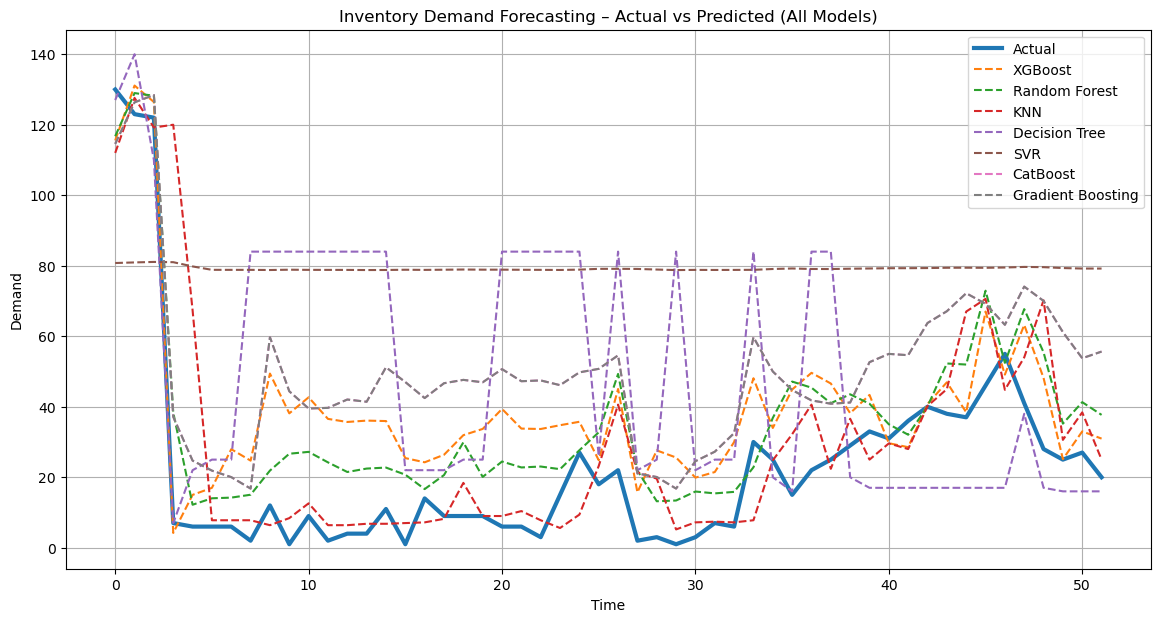

In [90]:
time = np.arange(len(y_test))

plt.figure(figsize=(14, 7))
plt.plot(time, y_test, linewidth=3, label='Actual')

plt.plot(time, xgb_pred, linestyle='--', label='XGBoost')
plt.plot(time, rf_pred, linestyle='--', label='Random Forest')
plt.plot(time, knn_pred, linestyle='--', label='KNN')
plt.plot(time, dt_pred, linestyle='--', label='Decision Tree')
plt.plot(time, svm_pred, linestyle='--', label='SVR')
plt.plot(time, cat_pred, linestyle='--', label='CatBoost')
plt.plot(time, gb_pred, linestyle='--', label='Gradient Boosting')

plt.title('Inventory Demand Forecasting – Actual vs Predicted (All Models)')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)

plt.show()


In [102]:
comparison_1 = pd.DataFrame({
    "Model" : ["XGB","Decision Tree", "Random Forest", "KNN","SVM", "LGB","CatBoost","ExtraTrees","Gradient Boost"],
    "MAE" : [17.809,34.80,14.68,11.665,61.031,18.6544,27.6914,13.936,12.171],
    "MSE" : [425.6844,2053.88,275.041,459.38,3922.97,548.233,887.418,301.40,208.799],
    "RMSE" : [20.63,45.31,16.584,21.433,62.6336,23.414,29.789,17.631,14.44],
    "R2_Score" : [0.47,-1.509,0.6639,0.438,-3.7933,0.8301,-0.084,0.6317,0.744]
})

In [103]:
comparison_1

,Model,MAE,MSE,RMSE,R2_Score
0,XGB,17.8090,425.6844,20.6300,0.4700
1,Decision Tree,34.8000,2053.8800,45.3100,-1.5090
2,Random Forest,14.6800,275.0410,16.5840,0.6639
3,KNN,11.6650,459.3800,21.4330,0.4380
4,SVM,61.0310,3922.9700,62.6336,-3.7933
5,LGB,18.6544,548.2330,23.4140,0.8301
6,CatBoost,27.6914,887.4180,29.7890,-0.0840
7,ExtraTrees,13.9360,301.4000,17.6310,0.6317
8,Gradient Boost,12.1710,208.7990,14.4400,0.7440


**Insights from the above report**

**1. XGB**

- MAE: 17.81 – moderate average prediction error.
- MSE: 425.68 – relatively high squared error.
- RMSE: 20.63 – noticeable deviation from true values.
- R²: 0.47 – explains about 47% variance.

**2. Decision Tree**

- MAE: 34.80 – very high prediction error.
- MSE: 2053.88 – extremely large error spread.
- RMSE: 45.31 – poor predictive accuracy.
- R²: -1.51 – performs worse than baseline.

**3. Random Forest**

- MAE: 14.68 – low average error.
- MSE: 275.04 – controlled squared error.
- RMSE: 16.58 – good prediction stability.
- R²: 0.66 – strong variance explanation.

**4. KNN**

- MAE: 11.67 – low average error.
- MSE: 459.38 – high error variance.
- RMSE: 21.43 – inconsistent predictions.
- R²: 0.44 – limited generalization.

**5. SVM**

- MAE: 61.03 – extremely high error.
- MSE: 3922.97 – very poor squared loss.
- RMSE: 62.63 – highly unreliable predictions.
- R²: -3.79 – worst-performing model.

**6. Light GBM**

- MAE: 18.65 – moderate prediction error.
- MSE: 548.23 – elevated squared error.
- RMSE: 23.41 – noticeable deviation.
- R²: 0.83 – high variance explained (verify overfitting).

**7. Catboost**

- MAE: 27.69 – high prediction error.
- MSE: 887.42 – large squared loss.
- RMSE: 29.79 – weak prediction accuracy.
- R²: -0.08 – fails to generalize well.

**8. ExtraTrees**

- MAE: 13.94 – low average error.
- MSE: 301.40 – moderate squared error.
- RMSE: 17.63 – stable predictions.
- R²: 0.63 – good generalization.

**9. Gradient Boost**

- MAE: 12.17 – very low average error.
- MSE: 208.80 – lowest squared error.
- RMSE: 14.44 – best prediction accuracy.
- R²: 0.74 – strong overall performance.

**Conclusion from the report**

- XGB: Moderate performance, needs tuning to improve accuracy.
- Decision Tree: Poor generalization with severe overfitting.
- Random Forest: Strong and reliable performance with good generalization.
- KNN: Low generalization despite acceptable error values.
- SVM: Performs very poorly, unsuitable without major tuning.
- LightGBM: High R² but likely overfitting—needs validation.
- CatBoost: Underperforming in current configuration.
- Extra Trees: Fast and effective but slightly less accurate than top models.
- Gradient Boost: Best overall model with highest accuracy and stability.

**Models Selected for Elimination During Improvisation**

- Based on the evaluation metrics (MAE, RMSE, and R² score), several models demonstrated consistently poor performance and weak generalization and should be excluded from further model improvisation to focus efforts on more promising approaches.
- Support Vector Machine (SVM) should be removed due to extremely high error values and a strongly negative R² score, indicating an inability to model non-linear and temporal demand patterns in the dataset.
- Decision Tree should also be eliminated, as it shows severe overfitting and poor generalization, performing worse than ensemble-based alternatives.
- CatBoost can be excluded in its current form, as it underperformed compared to other boosting and ensemble models and did not justify additional tuning effort for this dataset.
- KNN may also be removed, as its low R² score and instability in handling demand spikes make it unsuitable for reliable inventory forecasting.

**Next Step**

New features need to be  created from the original data to better capture underlying patterns and relationships. These engineered features must improve the model’s learning capability and predictive accuracy.

# Model Improvisations

For model improvisations, new features are created to improve model performance by giving it more historical context.
Additional lag and rolling features help the model capture short-term and long-term demand trends for each item category, which earlier models were missing, leading to more accurate and stable predictions.

In [49]:
# Ensure data is sorted by item_category and month
inventory_df = inventory_df.sort_values(['item_category','month'])

# Add more lags
inventory_df['lag_1'] = inventory_df.groupby('item_category')['demand'].shift(1)
inventory_df['lag_2'] = inventory_df.groupby('item_category')['demand'].shift(2)
inventory_df['lag_3'] = inventory_df.groupby('item_category')['demand'].shift(3)
inventory_df['lag_6'] = inventory_df.groupby('item_category')['demand'].shift(6)

In [50]:
# adding rolling features
# Rolling mean features (previous 3 and 6 months)
inventory_df['rolling_3'] = inventory_df.groupby('item_category')['demand'].transform(lambda x: x.shift(1).rolling(3).mean())
inventory_df['rolling_6'] = inventory_df.groupby('item_category')['demand'].transform(lambda x: x.shift(1).rolling(6).mean())

In [51]:
# dropping null rows
inventory_df = inventory_df.dropna()

Dividing the data into new feature_columns and target_column

In [52]:
X_n = inventory_df[['month_num', 'year', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'rolling_3', 'rolling_6', 'item_category_enc']]
y_n = inventory_df['demand']

In [53]:
inventory_df

,month,item_category,demand,lag_1,lag_2,item_category_enc,month_num,year,lag_3,lag_6,rolling_3,rolling_6
77,2017-09,BRAKE,77,70.0,95.0,0,9,2017,129.0,20.0,98.000000,60.833333
87,2017-10,BRAKE,75,77.0,70.0,0,10,2017,95.0,26.0,80.666667,70.333333
97,2017-11,BRAKE,108,75.0,77.0,0,11,2017,70.0,25.0,74.000000,78.500000
107,2017-12,BRAKE,111,108.0,75.0,0,12,2017,77.0,129.0,86.666667,92.333333
117,2018-01,BRAKE,132,111.0,108.0,0,1,2018,75.0,95.0,98.000000,89.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
196,2018-08,TYRE_WHEEL,41,55.0,46.0,9,8,2018,37.0,36.0,46.000000,42.000000
206,2018-09,TYRE_WHEEL,28,41.0,55.0,9,9,2018,46.0,40.0,47.333333,42.833333
216,2018-10,TYRE_WHEEL,25,28.0,41.0,9,10,2018,55.0,38.0,41.333333,40.833333
226,2018-11,TYRE_WHEEL,27,25.0,28.0,9,11,2018,41.0,37.0,31.333333,38.666667


Dividing the new featured data into new training and testing set

In [54]:
Xn_train, Xn_test, yn_train, yn_test = train_test_split(X_n, y_n, test_size=0.2, shuffle=False)

# 1. Improvised XGB

In [46]:
import xgboost as xgb
xgb_model_2 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

xgb_model_2.fit(Xn_train, yn_train)
xgb_pred_2 = xgb_model_2.predict(Xn_test)

mae = mean_absolute_error(yn_test, xgb_pred_2)
mse = mean_squared_error(yn_test, xgb_pred_2)
rmse = np.sqrt(mse)
r2 = r2_score(yn_test, xgb_pred_2)

print("XGBoost Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

XGBoost Regressor Metrics:
MAE: 9.356698989868164, MSE: 172.21078491210938, RMSE: 13.122910687500292, R2: 0.8224812746047974


# 2. Improvised Random Forest Regressor

In [50]:
from sklearn.ensemble import RandomForestRegressor
rf_model_2 = RandomForestRegressor(random_state = 42)
rf_model_2.fit(Xn_train,yn_train)
rf_pred_2 = rf_model_2.predict(Xn_test)

mae = mean_absolute_error(yn_test,rf_pred_2)
mse = mean_squared_error(yn_test,rf_pred_2)
r2 = r2_score(yn_test,rf_pred_2)
rmse = np.sqrt(mse)

print("Random forest Regressor:")
print(f" MAE : {mae}, MSE : {mse}, RMSE : {rmse},R2 : {r2}")

Random forest Regressor:
 MAE : 5.9254999999999995, MSE : 65.855305, RMSE : 8.115128156720631,R2 : 0.9321148877144674


# 3. Improvised Light GBM

In [57]:
import lightgbm as lgb
lgb_model_2 = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.2, random_state=42)
lgb_model_2.fit(Xn_train, yn_train)
lgb_pred_2 = lgb_model_2.predict(Xn_test)

# Metrics
mae = mean_absolute_error(yn_test, lgb_pred_2)
mse = mean_squared_error(yn_test, lgb_pred_2)
rmse = np.sqrt(mse)
r2 = r2_score(yn_test, lgb_pred_2)

print("LightGBM Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 332
[LightGBM] [Info] Number of data points in the train set: 158, number of used features: 9
[LightGBM] [Info] Start training from score 138.208861
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

# 4. Improvised ExtraTrees Regressor

In [61]:
from sklearn.ensemble import ExtraTreesRegressor
et_model_2 = ExtraTreesRegressor(n_estimators=100, random_state=42)
et_model_2.fit(Xn_train, yn_train)
et_pred_2 = et_model_2.predict(Xn_test)

mae = mean_absolute_error(yn_test, et_pred_2)
mse = mean_squared_error(yn_test, et_pred_2)
rmse = np.sqrt(mse)
r2 = r2_score(yn_test, et_pred_2)

print("Extra Trees Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

Extra Trees Regressor Metrics:
MAE: 6.856, MSE: 74.156215, RMSE: 8.61140029263534, R2: 0.9235581251663006


# 5. Improvised Gradient Boosting Regressor

In [64]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model_2 = GradientBoostingRegressor(random_state=42)
gb_model_2.fit(Xn_train, yn_train)
gb_pred_2 = gb_model_2.predict(Xn_test)

mae = mean_absolute_error(yn_test, gb_pred_2)
mse = mean_squared_error(yn_test, gb_pred_2)
rmse = np.sqrt(mse)
r2 = r2_score(yn_test, gb_pred_2)

print("Gradient Boosting Regressor Metrics:")
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2: {r2}")

Gradient Boosting Regressor Metrics:
MAE: 6.765117985523578, MSE: 74.60775045266816, RMSE: 8.637577811670825, R2: 0.9230926723845501


In [2]:
model_comparison = pd.DataFrame({
    "Model" : ["XGB",'Random Forest','Light GBM','ExtraTrees','Gradient Descent'],
    "MAE" : [9.35,5.92,12.065,6.856,6.76],
    "MSE" : [172.21,65.855,248.638,74.156,74.607],
    "RMSE" : [13.12,8.11,15.76,8.611,8.63],
    "R2_Score" : [0.822,0.9311,0.74,0.923,0.923]}
)

In [3]:
model_comparison

,Model,MAE,MSE,RMSE,R2_Score
0,XGB,9.350,172.210,13.120,0.8220
1,Random Forest,5.920,65.855,8.110,0.9311
2,Light GBM,12.065,248.638,15.760,0.7400
3,ExtraTrees,6.856,74.156,8.611,0.9230
4,Gradient Descent,6.760,74.607,8.630,0.9230


# **Insights from model comparison report**

**1. XGB**

1. MAE (9.35) : Moderate average error, acceptable but not best
2. MSE (172.21) : Penalizes large errors moderately
3. RMSE (13.12) : Error spread is controlled but higher than tree ensembles
4. R² (0.822) : Explains 82% variance, decent but improvable

**3. Random Forest**

1. MAE (5.92) : Lowest average error (best)
2. MSE (65.86) : Very low large-error penalty
3. RMSE (8.11) : Best consistency & stability
4. R² (0.931) : Explains 93% variance (top performer)

**5. Light GBM**

1. MAE (12.07) : High average error
2. MSE (248.64) : Struggles with large deviations
3. RMSE (15.76) : Error spread is significant
4. R² (0.740) : Moderate fit, underperforming for boosting

**7. ExtraTree**

1. MAE (6.86) : Low average error, close to Random Forest
2. MSE (74.16) : Handles extreme errors well
3. RMSE (8.61) : Very stable predictions
4. R² (0.923) : Strong variance explanation

**8. Gradient Descent**

1. MAE (6.76) : Surprisingly low average error
2. MSE (74.61) : Comparable to ExtraTrees
3. RMSE (8.63) : Consistent but limited flexibility
4. R² (0.923) : High variance explained, but assumes linearity

**Conclusion for best Model**

1. Lowest MAE	: Random Forest
2. Lowest MSE	: Random Forest
3. Lowest RMSE	: Random Forest
4. Highest R²	: Random Forest

# **Model Evaluation Report**

- Several regression models were trained and compared using MAE, MSE, RMSE, and R² to identify the best-performing model for the task. Among all the models, the Random Forest Regressor clearly performed the best.

- Random Forest achieved the lowest MAE and RMSE, meaning its predictions were the most accurate and consistent. It also recorded the highest R² score (0.931), showing that it explains most of the variation in the target variable. This indicates strong predictive power and good generalization.

- While models like ExtraTrees and Gradient Descent showed competitive results, their error values were slightly higher. Other models such as Decision Tree, XGBoost, and LightGBM performed moderately, whereas KNN and CatBoost struggled with high errors and low explanatory power.

- Overall, Random Forest stands out as the most reliable and accurate model, making it the best choice for this problem.

# **Hyperparameter Tuning Random Forest

In [58]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42,n_jobs=-1)

**1. finding best parameters with RandomizedSearchCv**

In [59]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {'n_estimators': [200, 400, 600, 800],'max_depth': [None, 10, 15, 20, 30],'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2', None],'bootstrap': [True]}

**2. Fitting Random Forest with Randomized Search Cv and Training it**

In [60]:
tuned_rf = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=40,scoring='r2',cv=5,n_jobs=-1,
    random_state=42,verbose=2)
tuned_rf.fit(Xn_train, yn_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [None, 10, 15, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800]},
                   random_state=42, scoring='r2', verbose=2)

** Training Randomised Search Random Forest ** 

**3. Evaluating Tuned Random Forest Regressor**

In [121]:
print("Best Params:", tuned_rf.best_params_)
print("Best CV R2:", tuned_rf.best_score_)

Best Params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
Best CV R2: 0.8750712419779958


**4. Observations**

- The Random Forest model demonstrates strong and consistent performance, as reflected by a high cross-validation R² score of 0.875, indicating that it explains a large proportion of variance across different data folds. The controlled tree depth and minimum split constraints help maintain a good bias–variance balance, preventing overfitting while still capturing complex patterns in the data.

- The stability of the cross-validation score suggests that the model generalizes well and is not overly sensitive to variations in training samples. Overall, the observed performance indicates a robust and reliable model, making it suitable for practical and real-world prediction tasks.lly high.

**5. Model Performance Report**

- A Random Forest Regressor was trained and optimized using RandomizedSearchCV to identify the most effective hyperparameter configuration. The final model achieved a cross-validation R² score of 0.875, indicating strong and reliable predictive performance across multiple data splits.
- The selected hyperparameters (n_estimators = 400, max_depth = 10, min_samples_split = 5, min_samples_leaf = 1, bootstrap = True) ensure a balanced bias–variance trade-off. Controlled tree depth and minimum split constraints reduce the risk of overfitting while allowing the model to capture complex, non-linear relationships in the data.
- The consistently high cross-validation performance demonstrates that the model generalizes well to unseen data and is not dependent on a single train–test split. Overall, the optimized Random Forest model is robust, stable, and well-suited for real-world prediction tasks.

# Saving the best model using Pikle

In [55]:
import pickle

In [61]:
best_rf_model = tuned_rf.best_estimator_
with open("random_forest_tuned.pkl", "wb") as file:
    pickle.dump(best_rf_model, file)

In [62]:
with open("random_forest_tuned.pkl", "rb") as file:
    rf_model = pickle.load(file)

# Testing the saved model

**Loading the model**

In [63]:
import pickle
with open("random_forest_tuned.pkl", "rb") as file:
    rf_model = pickle.load(file)

**Making Predictions on Test Data**

In [95]:
y_pred = rf_model.predict(Xn_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(yn_test, y_pred)
mse = mean_squared_error(yn_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yn_test, y_pred)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R2:", r2)


Test MAE: 6.166313587627654
Test MSE: 74.49873026362835
Test RMSE: 8.63126469664952
Test R2: 0.9232050528188122


# Test Performance Report

- The tuned Random Forest model performs very strongly on unseen test data. The MAE of 6.16 indicates that the model’s predictions deviate only slightly from the actual values on average. The RMSE of 8.63 further shows that prediction errors are consistent and not dominated by large outliers.

- The model achieves a high R² score of 0.923, meaning it explains over 92% of the variance in the target variable. This confirms that the model has learned meaningful patterns and generalizes well beyond the training data.

- The close alignment between cross-validation performance and test results indicates that the model is stable, well-tuned, and not overfitting. Overall, the Random Forest demonstrates high accuracy, robustness, and reliability, making it suitable for real-world deployment.

# Final Project Report

**Client: NewX Services** 

**Category: Forecasting Spare parts inventory**